In [49]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
import os

# Agrega la raíz del proyecto al path
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Conexión del proyecto
from scripts.database import engine

# Configuración visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas      {pd.__version__}")
print(f"   numpy       {np.__version__}")
print(f"   seaborn     {sns.__version__}")

✅ Librerías importadas correctamente
   pandas      2.2.2
   numpy       1.26.4
   seaborn     0.13.2


In [50]:
# ── CELDA 2: Carga de datos desde PostgreSQL ─────────────────

QUERY = """
SELECT
    nombre,
    fecha_lanzamiento,
    rating,
    metacritic,
    ratings_count,
    added,
    playtime,
    rating_top,
    platforms,
    genres,
    esrb_rating,
    developers,
    publishers
FROM videojuegos_top
ORDER BY fecha_lanzamiento
"""

df = pd.read_sql(QUERY, engine)

print("✅ Datos cargados exitosamente desde PostgreSQL")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")

df.head()

✅ Datos cargados exitosamente desde PostgreSQL
   Filas    : 40
   Columnas : 13


,nombre,fecha_lanzamiento,rating,metacritic,ratings_count,added,playtime,rating_top,platforms,genres,esrb_rating,developers,publishers
0,Grand Theft Auto: San Andreas,2004-10-26,4.50,93.0,4056,12117,2,5.0,"[""macOS"", ""PC"", ""iOS"", ""Xbox"", ""Android"", ""Pla...","[""Action""]",Mature,"[""Rockstar North"", ""War Drum Studios""]","[""Capcom"", ""Rockstar Games"", ""1C-SoftClub""]"
1,Half-Life 2,2004-11-16,4.48,96.0,4098,16100,7,5.0,"[""PC"", ""macOS"", ""Xbox 360"", ""Linux"", ""Xbox"", ""...","[""Action"", ""Shooter""]",Mature,"[""Valve Software"", ""NVIDIA Lightspeed Studios""]","[""Valve""]"
2,Half-Life 2: Lost Coast,2005-10-27,3.45,NaN,1173,11692,1,4.0,"[""macOS"", ""Linux"", ""PC""]","[""Action""]",Mature,"[""Valve Software""]","[""Valve""]"
3,BioShock,2007-08-21,4.36,96.0,3360,14766,3,5.0,"[""PlayStation 3"", ""macOS"", ""PC"", ""Xbox 360""]","[""Action"", ""Shooter""]",Mature,"[""Digital Extremes"", ""2K Australia"", ""2K Marin...","[""2K Games"", ""Feral Interactive""]"
4,Portal,2007-10-09,4.49,90.0,5012,17797,4,5.0,"[""macOS"", ""PC"", ""Android"", ""PlayStation 3"", ""X...","[""Action"", ""Puzzle""]",Teen,"[""Valve Software"", ""NVIDIA Lightspeed Studios""]","[""Valve"", ""Buka Entertainment"", ""NVIDIA"", ""Cyb..."


In [51]:
# ── CELDA 3: Inspección del DataFrame ────────────────────

df["fecha_lanzamiento"] = pd.to_datetime(df["fecha_lanzamiento"], errors="coerce")
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["metacritic"] = pd.to_numeric(df["metacritic"], errors="coerce")
df["ratings_count"] = pd.to_numeric(df["ratings_count"], errors="coerce")
df["added"] = pd.to_numeric(df["added"], errors="coerce")
df["playtime"] = pd.to_numeric(df["playtime"], errors="coerce")
df["rating_top"] = pd.to_numeric(df["rating_top"], errors="coerce")

# Procesar listas JSON
import json
df["platforms"] = df["platforms"].apply(lambda x: json.loads(x) if pd.notna(x) else [])
df["genres"] = df["genres"].apply(lambda x: json.loads(x) if pd.notna(x) else [])
df["developers"] = df["developers"].apply(lambda x: json.loads(x) if pd.notna(x) else [])
df["publishers"] = df["publishers"].apply(lambda x: json.loads(x) if pd.notna(x) else [])

# Derivar variables
df["año"] = df["fecha_lanzamiento"].dt.year
df["edad_juego"] = 2024 - df["año"]  # Asumiendo año actual 2024
df["num_genres"] = df["genres"].apply(len)
df["num_platforms"] = df["platforms"].apply(len)
df["num_developers"] = df["developers"].apply(len)
df["num_publishers"] = df["publishers"].apply(len)

print("=" * 50)
print("  INFORMACIÓN GENERAL DEL DATASET")
print("=" * 50)

print(df.info())

print("\n📊 Valores nulos por columna:")
print(df.isnull().sum())

print("\n🎮 Juegos en el dataset:")
print(df["nombre"].nunique())

  INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   nombre             40 non-null     object        
 1   fecha_lanzamiento  40 non-null     datetime64[ns]
 2   rating             40 non-null     float64       
 3   metacritic         39 non-null     float64       
 4   ratings_count      40 non-null     int64         
 5   added              40 non-null     int64         
 6   playtime           40 non-null     int64         
 7   rating_top         40 non-null     float64       
 8   platforms          40 non-null     object        
 9   genres             40 non-null     object        
 10  esrb_rating        37 non-null     object        
 11  developers         40 non-null     object        
 12  publishers         40 non-null     object        
 13  año                40 non-null   

In [52]:
# ── CELDA 4: Estadísticas descriptivas ───────────────────────

vars_num = ["rating", "metacritic", "ratings_count", "added", "playtime", "rating_top", "año", "edad_juego", "num_genres", "num_platforms", "num_developers", "num_publishers"]

desc = df[vars_num].describe().round(2)

print("📊 ESTADÍSTICAS DESCRIPTIVAS")
print(desc)

📊 ESTADÍSTICAS DESCRIPTIVAS
       rating  metacritic  ratings_count     added  playtime  rating_top  \
count   40.00       39.00          40.00     40.00     40.00       40.00   
mean     4.10       87.51        3486.88  14670.85     15.58        4.42   
std      0.38        6.14        1350.79   2841.76     16.27        0.55   
min      3.07       73.00        1173.00  11678.00      1.00        3.00   
25%      3.92       83.50        2547.50  12371.25      6.75        4.00   
50%      4.15       88.00        3209.00  14034.00     10.00        4.00   
75%      4.38       92.00        4065.25  16101.50     16.00        5.00   
max      4.64       96.00        7368.00  22550.00     74.00        5.00   

           año  edad_juego  num_genres  num_platforms  num_developers  \
count    40.00       40.00       40.00          40.00           40.00   
mean   2012.48       11.52        1.98           5.45            1.82   
std       4.06        4.06        0.86           2.63            1.4

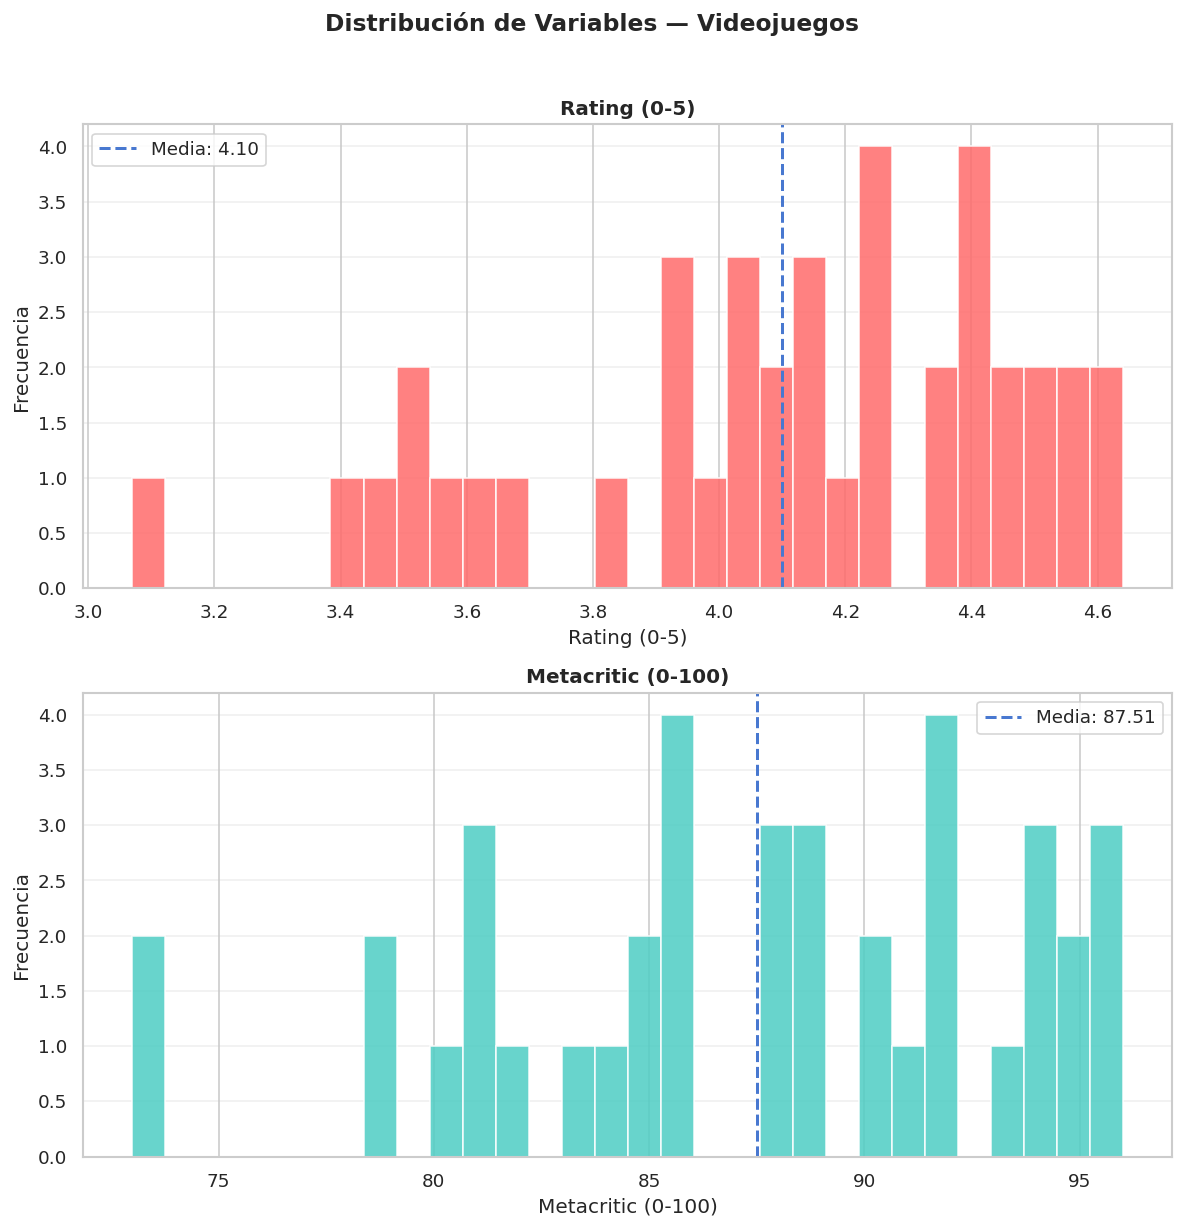

In [53]:
# ── CELDA 5: Histogramas de distribución ─────────────────────

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

fig.suptitle('Distribución de Variables — Videojuegos',
             fontsize=14, fontweight='bold', y=1.02)

datos = {
    'rating':     ('Rating (0-5)', '#ff6b6b'),
    'metacritic': ('Metacritic (0-100)', '#4ecdc4'),
}

for ax, (col, (label, color)) in zip(axes.flat, datos.items()):
    valores = df[col].dropna()

    ax.hist(valores, bins=30, color=color, edgecolor='white', alpha=0.85)

    media = valores.mean()
    ax.axvline(media, linestyle='--', linewidth=1.8,
               label=f'Media: {media:.2f}')

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig('../data/graficas/eda_distribuciones.png',
            dpi=150, bbox_inches='tight')

plt.show()

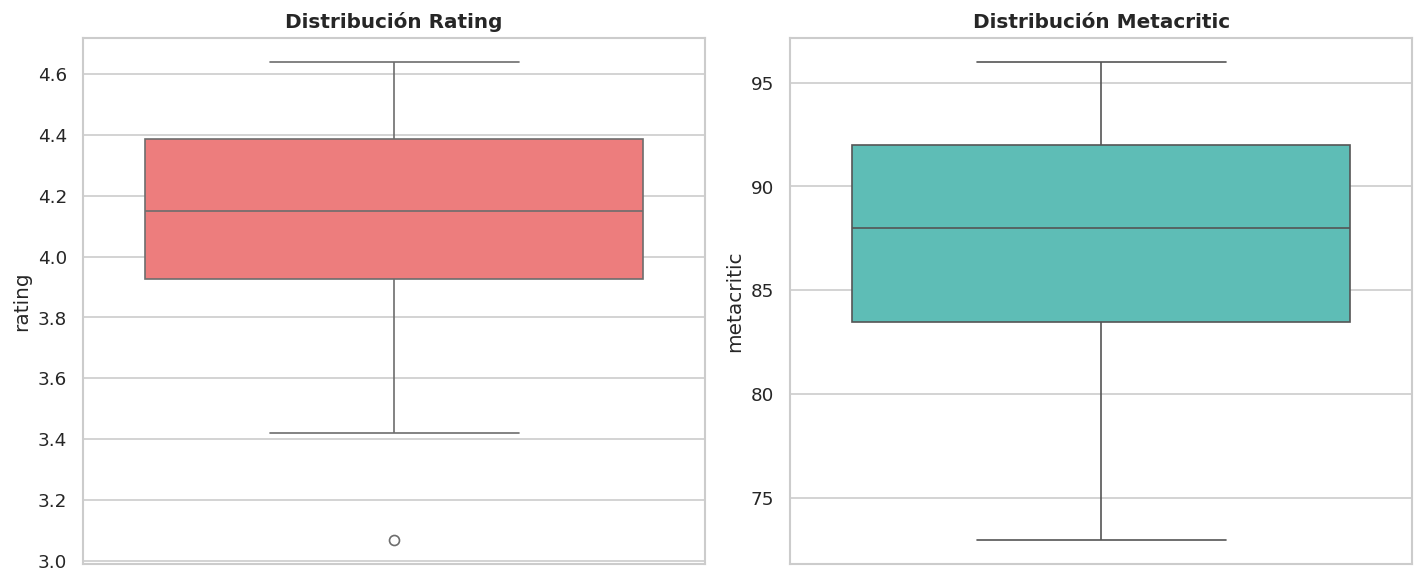

In [54]:
# ── CELDA 6: Boxplots ───────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, y='rating', ax=axes[0], color="#ff6b6b")
axes[0].set_title('Distribución Rating', fontweight='bold')

sns.boxplot(data=df, y='metacritic', ax=axes[1], color="#4ecdc4")
axes[1].set_title('Distribución Metacritic', fontweight='bold')

plt.tight_layout()

plt.savefig('../data/graficas/eda_boxplots.png',
            dpi=150, bbox_inches='tight')

plt.show()

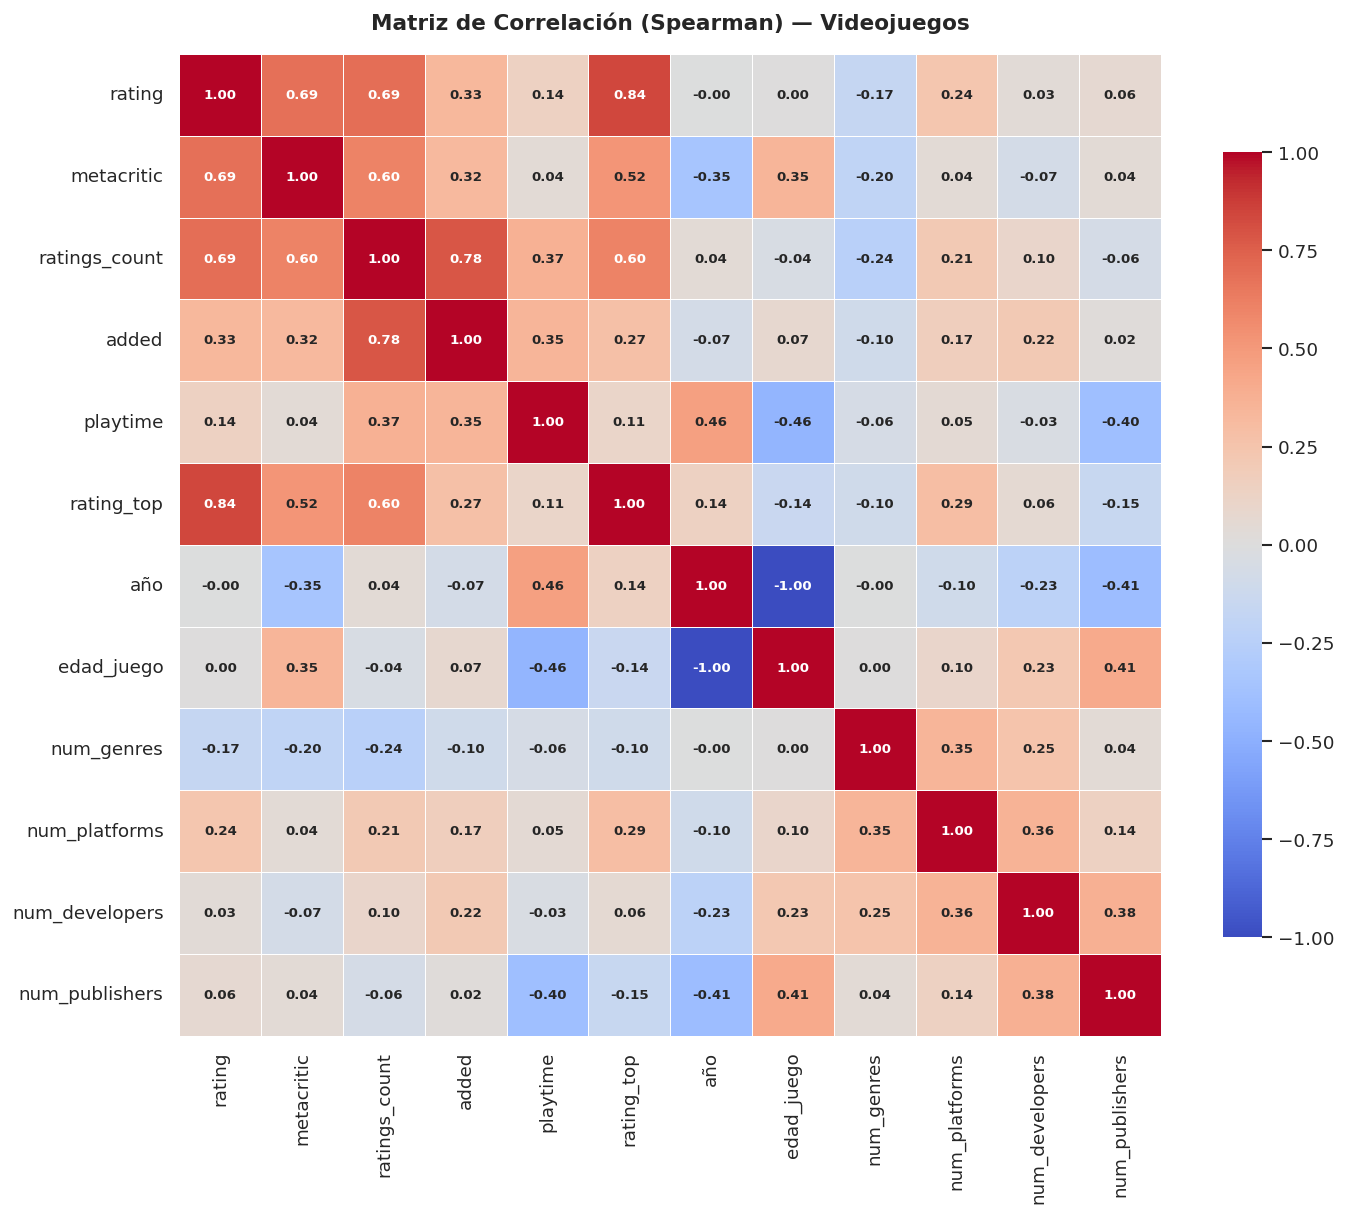


📊 Correlación (Spearman) con metacritic:
rating            0.6859
ratings_count     0.6044
rating_top        0.5194
edad_juego        0.3507
added             0.3229
num_platforms     0.0449
playtime          0.0443
num_publishers    0.0422
num_developers   -0.0714
num_genres       -0.1965
año              -0.3507
Name: metacritic, dtype: float64


In [55]:
# ── CELDA 7: Matriz de correlación (Spearman) ───────────────────────────

corr = df[vars_num].corr(method='spearman')

plt.figure(figsize=(12, 10))

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.6,
    square=True,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 8, 'weight': 'bold'}
)

plt.title('Matriz de Correlación (Spearman) — Videojuegos',
          fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()

plt.savefig('../data/graficas/eda_correlacion_spearman.png',
            dpi=150, bbox_inches='tight')

plt.show()

print("\n📊 Correlación (Spearman) con metacritic:")
print(corr["metacritic"].drop("metacritic").sort_values(ascending=False).round(4))

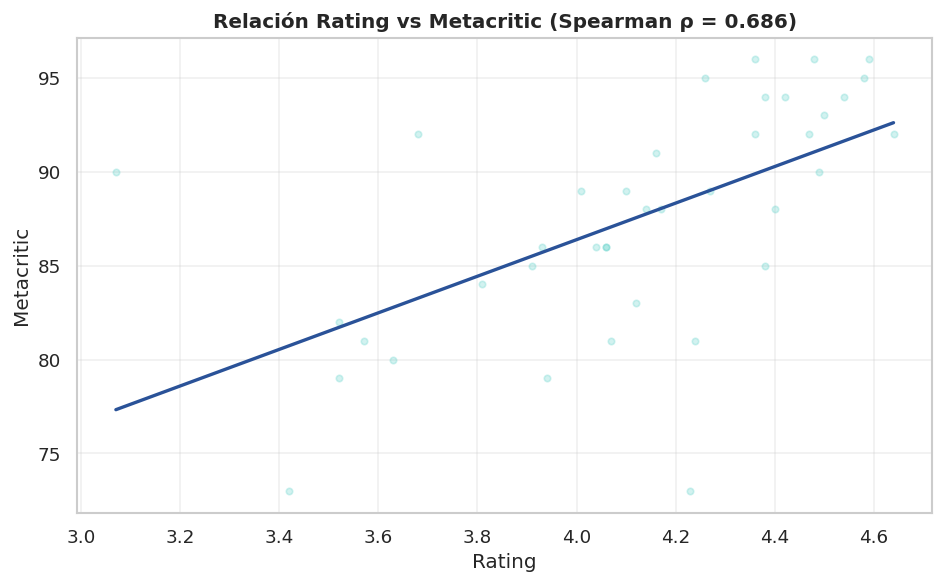

In [56]:
# ── CELDA 8: Scatter plots rating vs metacritic (Spearman) ─────────────

df_clean = df.dropna(subset=["rating", "metacritic"])

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    df_clean["rating"],
    df_clean["metacritic"],
    alpha=0.25,
    s=15,
    color="#4ecdc4"
)

# Línea de tendencia (regresión lineal solo para visualización)
z = np.polyfit(df_clean["rating"], df_clean["metacritic"], 1)
p = np.poly1d(z)

xp = np.linspace(df_clean["rating"].min(), df_clean["rating"].max(), 200)

ax.plot(xp, p(xp), color='#2a5298', linewidth=2)

# Correlación Spearman
r = df_clean[["rating", "metacritic"]].corr(method='spearman').iloc[0, 1]

ax.set_title(f'Relación Rating vs Metacritic (Spearman ρ = {r:.3f})',
             fontweight='bold')

ax.set_xlabel("Rating")
ax.set_ylabel("Metacritic")

ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig('../data/graficas/eda_scatter_spearman.png',
            dpi=150, bbox_inches='tight')

plt.show()

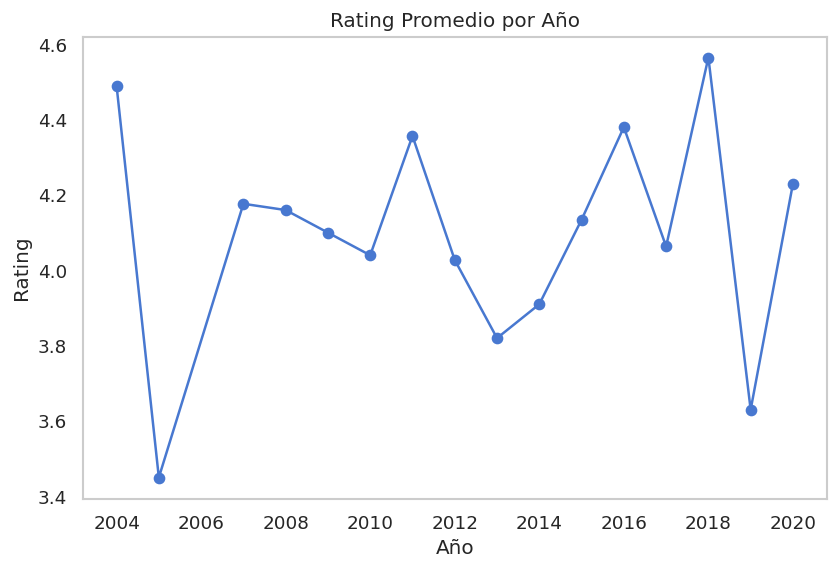

In [57]:
# ── CELDA 9: Evolución temporal ─────────────────────────────

df_time = df.dropna(subset=["fecha_lanzamiento"]).copy()
df_time["Año"] = df_time["fecha_lanzamiento"].dt.year

trend = df_time.groupby("Año")["rating"].mean().reset_index()

plt.figure(figsize=(8, 5))
plt.plot(trend["Año"], trend["rating"], marker="o")

plt.title("Rating Promedio por Año")
plt.xlabel("Año")
plt.ylabel("Rating")

plt.grid()
plt.show()

In [58]:
# ── CELDA 9: Split Train / Test ───────────────────────────────

# Usamos solo datos con metacritic
df_model = df.dropna(subset=['rating', 'metacritic']).copy()

X_simple = df_model[['rating']].values
y        = df_model['metacritic'].values

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.20, random_state=42
)

print(f"Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(y)*100:.0f}%)")
print(f"Test : {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(y)*100:.0f}%)")

Train: 31 muestras (79%)
Test : 8 muestras (21%)


In [59]:
# ── CELDA 10: Entrenamiento con scikit-learn ──────────────────

from sklearn.linear_model import LinearRegression

modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)

y_pred_simple = modelo_simple.predict(X_test)

print(f"Intercepto  β₀ : {modelo_simple.intercept_:.4f}")
print(f"Coeficiente β₁ : {modelo_simple.coef_[0]:.4f}")

print(f"\nEcuación : metacritic = {modelo_simple.intercept_:.3f}"
      f" + {modelo_simple.coef_[0]:.3f} × rating")

Intercepto  β₀ : 44.8028
Coeficiente β₁ : 10.3506

Ecuación : metacritic = 44.803 + 10.351 × rating


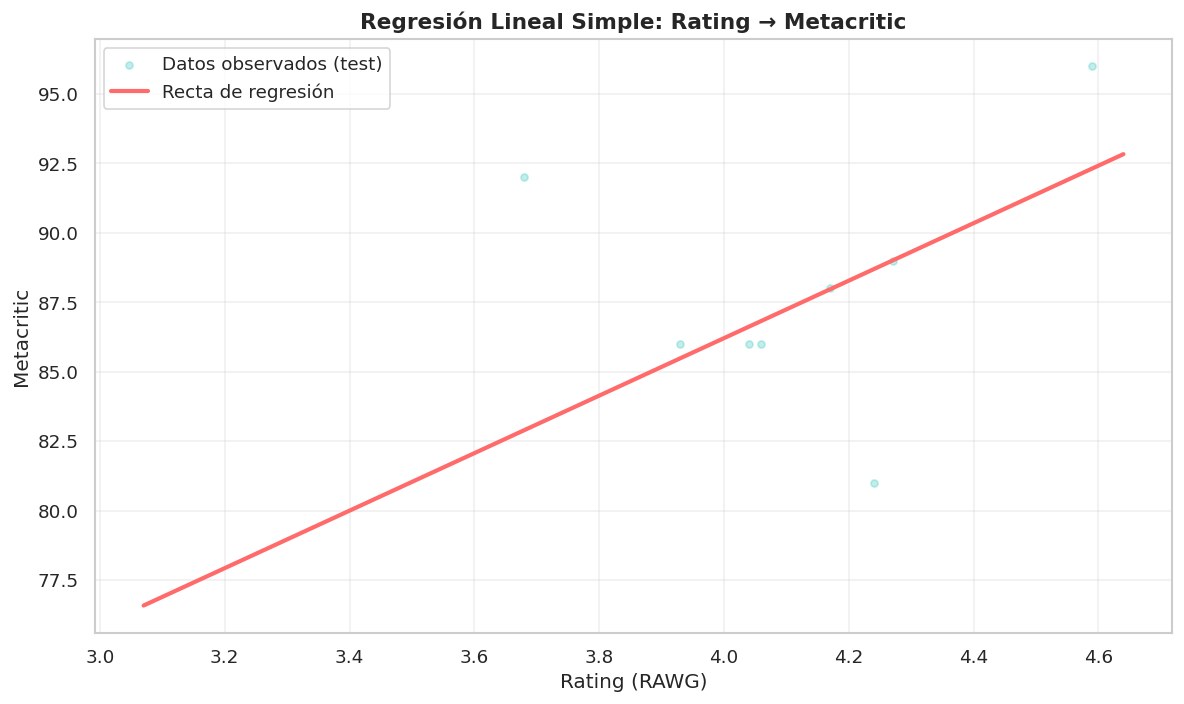

In [60]:
# ── CELDA 11: Recta de regresión ─────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

# puntos reales
ax.scatter(X_test, y_test, alpha=0.35, s=18,
           color='#4ecdc4', label='Datos observados (test)')

# línea de regresión
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(x_line, modelo_simple.predict(x_line),
        color='#ff6b6b', linewidth=2.5, label='Recta de regresión')

ax.set_xlabel('Rating (RAWG)', fontsize=12)
ax.set_ylabel('Metacritic', fontsize=12)
ax.set_title('Regresión Lineal Simple: Rating → Metacritic',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/regresion_simple_videojuegos.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [61]:
# ── CELDA 12: Métricas del modelo simple ─────────────────────

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

r2   = r2_score(y_test, y_pred_simple)
mse  = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_simple)

print("=" * 48)
print("    MÉTRICAS — REGRESIÓN LINEAL SIMPLE")
print("=" * 48)
print(f"  R²   (coef. determinación)  : {r2:.4f}  ({r2*100:.2f}%)")
print(f"  MSE  (error cuadrático med) : {mse:.4f}")
print(f"  RMSE (raíz del MSE)         : {rmse:.4f}")
print(f"  MAE  (error absoluto medio) : {mae:.4f}")
print("=" * 48)

    MÉTRICAS — REGRESIÓN LINEAL SIMPLE
  R²   (coef. determinación)  : -0.1056  (-10.56%)
  MSE  (error cuadrático med) : 19.6252
  RMSE (raíz del MSE)         : 4.4300
  MAE  (error absoluto medio) : 2.8106


In [62]:
# ── CELDA 13: OLS statsmodels — resumen completo ─────────────

import statsmodels.api as sm

X_ols = sm.add_constant(df_model['rating'])
modelo_ols_simple = sm.OLS(df_model['metacritic'], X_ols).fit()

print(modelo_ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:             metacritic   R-squared:                       0.344
Model:                            OLS   Adj. R-squared:                  0.326
Method:                 Least Squares   F-statistic:                     19.38
Date:                Sun, 12 Apr 2026   Prob (F-statistic):           8.77e-05
Time:                        21:08:00   Log-Likelihood:                -117.38
No. Observations:                  39   AIC:                             238.8
Df Residuals:                      37   BIC:                             242.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         47.4303      9.140      5.189      0.0

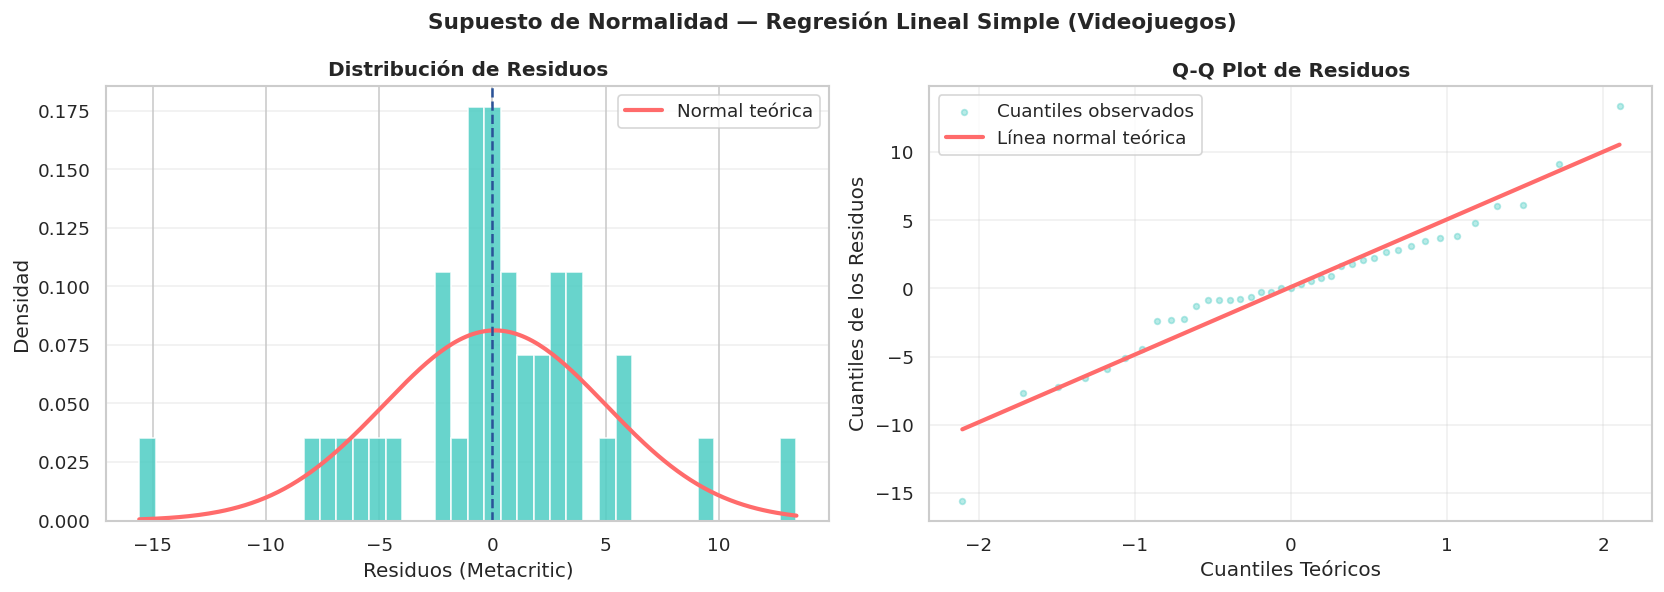


🔬 Test de Shapiro-Wilk:
   Estadístico W : 0.9521
   p-value       : 0.096436
   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)


In [63]:
# ── CELDA 14: Normalidad de residuos (modelo simple) ─────────

# Predicciones sobre TODO el dataset limpio
y_pred_all = modelo_simple.predict(df_model[['rating']].values)
residuos   = df_model['metacritic'].values - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supuesto de Normalidad — Regresión Lineal Simple (Videojuegos)',
             fontsize=13, fontweight='bold')

# Histograma
axes[0].hist(residuos, bins=40, color='#4ecdc4',
             edgecolor='white', density=True, alpha=0.85)

xr = np.linspace(residuos.min(), residuos.max(), 200)

axes[0].plot(
    xr,
    stats.norm.pdf(xr, residuos.mean(), residuos.std()),
    color='#ff6b6b',
    linewidth=2.5,
    label='Normal teórica'
)

axes[0].axvline(0, color='#2a5298', linestyle='--', linewidth=1.5)

axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos (Metacritic)')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Q-Q Plot
(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')

axes[1].scatter(osm, osr, alpha=0.4, s=12, color='#4ecdc4',
                label='Cuantiles observados')

axes[1].plot(osm,
             slope * np.array(osm) + intercept,
             color='#ff6b6b',
             linewidth=2.5,
             label='Línea normal teórica')

axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles de los Residuos')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/normalidad_simple_videojuegos.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Test Shapiro-Wilk
muestra_sw = (residuos if len(residuos) <= 5000
              else np.random.default_rng(42).choice(residuos, 5000, replace=False))

stat_sw, p_sw = stats.shapiro(muestra_sw)

print(f"\n🔬 Test de Shapiro-Wilk:")
print(f"   Estadístico W : {stat_sw:.4f}")
print(f"   p-value       : {p_sw:.6f}")

if p_sw > 0.05:
    print("   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)")
else:
    print("   Conclusión    : ⚠️ Se rechaza normalidad (p ≤ 0.05)")
    print("   Nota: Con datasets grandes esto es normal → revisa el Q-Q plot")

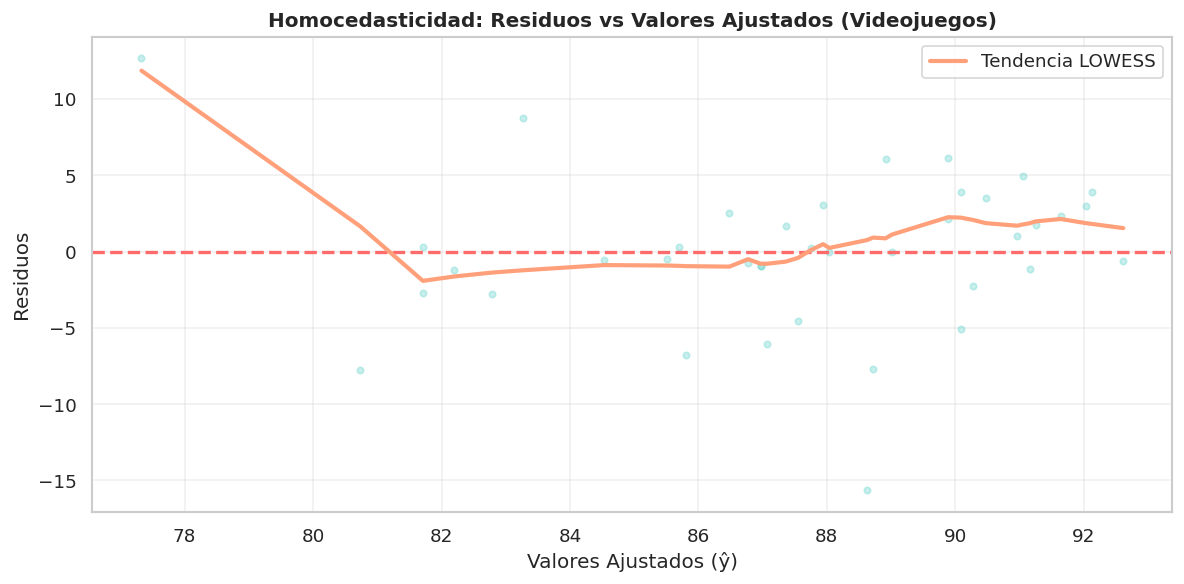


🔬 Test de Breusch-Pagan:
   Estadístico LM : 2.5812
   p-value        : 0.108137
   Conclusión     : ✅ Homocedasticidad (p > 0.05)


In [64]:
# ── CELDA 15: Homocedasticidad (modelo simple) ───────────────

residuos_ols  = modelo_ols_simple.resid
ajustados_ols = modelo_ols_simple.fittedvalues

plt.figure(figsize=(10, 5))

plt.scatter(ajustados_ols, residuos_ols,
            alpha=0.30, s=15, color='#4ecdc4')

plt.axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)

# LOWESS
lowess = sm.nonparametric.lowess(residuos_ols, ajustados_ols, frac=0.3)

plt.plot(lowess[:, 0], lowess[:, 1],
         color='#ffa07a', linewidth=2.5,
         label='Tendencia LOWESS')

plt.xlabel('Valores Ajustados (ŷ)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)

plt.title('Homocedasticidad: Residuos vs Valores Ajustados (Videojuegos)',
          fontsize=12, fontweight='bold')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/homoc_simple_videojuegos.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Test Breusch-Pagan
lm, lm_p, fval, fp = het_breuschpagan(
    residuos_ols,
    modelo_ols_simple.model.exog
)

print(f"\n🔬 Test de Breusch-Pagan:")
print(f"   Estadístico LM : {lm:.4f}")
print(f"   p-value        : {lm_p:.6f}")

if lm_p > 0.05:
    print("   Conclusión     : ✅ Homocedasticidad (p > 0.05)")
else:
    print("   Conclusión     : ⚠️ Heterocedasticidad detectada (p ≤ 0.05)")

In [65]:
# ── CELDA 16: Preparación y entrenamiento — modelo múltiple ──

# Crear variable año
df_model_multi = df.dropna(subset=['rating', 'metacritic', 'fecha_lanzamiento']).copy()

FEATURES = ['rating', 'año', 'edad_juego', 'ratings_count', 'added', 'playtime', 'rating_top', 'num_genres', 'num_platforms', 'num_developers', 'num_publishers']

X_multi = df_model_multi[FEATURES].values
y       = df_model_multi['metacritic'].values

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.20, random_state=42
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

y_pred_multi = modelo_multi.predict(X_test_m)

print(f"Intercepto  β₀ : {modelo_multi.intercept_:.4f}")

for feat, coef in zip(FEATURES, modelo_multi.coef_):
    print(f"Coeficiente {feat:>15} : {coef:.4f}")

Intercepto  β₀ : 757.1343
Coeficiente          rating : 9.0641
Coeficiente             año : -0.3406
Coeficiente      edad_juego : 0.3406
Coeficiente   ratings_count : 0.0035
Coeficiente           added : -0.0010
Coeficiente        playtime : -0.0533
Coeficiente      rating_top : -3.7474
Coeficiente      num_genres : -0.8668
Coeficiente   num_platforms : -0.1362
Coeficiente  num_developers : -0.1064
Coeficiente  num_publishers : -1.5222


/tmp/ipykernel_17099/3179149538.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(FEATURES, rotation=45, ha='right')


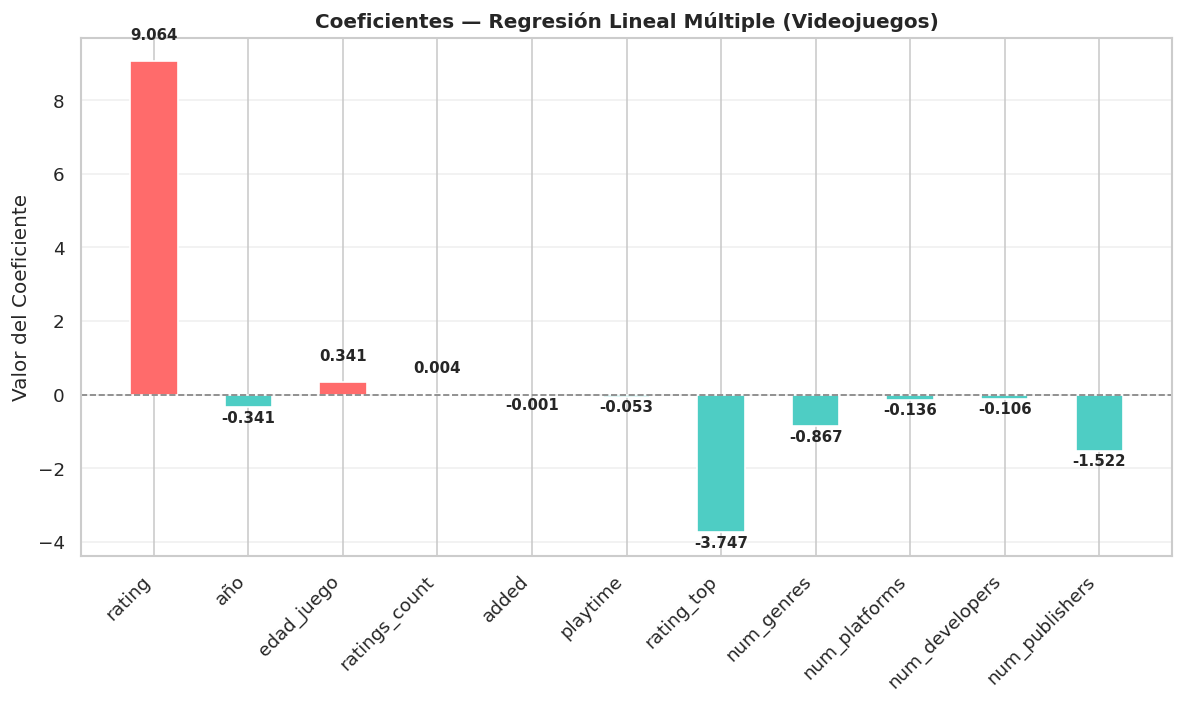

In [66]:
# ── CELDA 17: Gráfica de coeficientes ────────────────────────

colores = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in modelo_multi.coef_]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(FEATURES, modelo_multi.coef_,
              color=colores, edgecolor='white', width=0.5)

ax.axhline(0, color='gray', linestyle='--', linewidth=1)

ax.set_title('Coeficientes — Regresión Lineal Múltiple (Videojuegos)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Valor del Coeficiente')
ax.set_xticklabels(FEATURES, rotation=45, ha='right')

for bar, coef in zip(bars, modelo_multi.coef_):
    offset = 0.5 if coef >= 0 else -0.5
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            f'{coef:.3f}',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold')

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/coeficientes_multi_videojuegos.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [67]:
# ── CELDA 18: Métricas — modelo múltiple ─────────────────────

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

r2_m   = r2_score(y_test_m, y_pred_multi)
mse_m  = mean_squared_error(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mse_m)
mae_m  = mean_absolute_error(y_test_m, y_pred_multi)

print("=" * 48)
print("  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE")
print("=" * 48)
print(f"  R²   (coef. determinación)  : {r2_m:.4f}  ({r2_m*100:.2f}%)")
print(f"  MSE  (error cuadrático med) : {mse_m:.4f}")
print(f"  RMSE (raíz del MSE)         : {rmse_m:.4f}")
print(f"  MAE  (error absoluto medio) : {mae_m:.4f}")
print("=" * 48)

  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE
  R²   (coef. determinación)  : 0.2011  (20.11%)
  MSE  (error cuadrático med) : 14.1802
  RMSE (raíz del MSE)         : 3.7657
  MAE  (error absoluto medio) : 2.4591


In [68]:
# ── CELDA 19: OLS statsmodels — modelo múltiple ──────────────

import statsmodels.api as sm

X_ols_m = sm.add_constant(df_model_multi[FEATURES])
modelo_ols_multi = sm.OLS(df_model_multi['metacritic'], X_ols_m).fit()

print(modelo_ols_multi.summary())

                            OLS Regression Results                            
Dep. Variable:             metacritic   R-squared:                       0.640
Model:                            OLS   Adj. R-squared:                  0.512
Method:                 Least Squares   F-statistic:                     4.981
Date:                Sun, 12 Apr 2026   Prob (F-statistic):           0.000366
Time:                        21:08:34   Log-Likelihood:                -105.67
No. Observations:                  39   AIC:                             233.3
Df Residuals:                      28   BIC:                             251.6
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0004      0.000      3.

In [69]:
# ── CELDA 20: VIF — Factor de Inflación de la Varianza ───────

# Calcular VIF para TODAS las variables del modelo múltiple
X_vif = df_model_multi[FEATURES].dropna().copy()

vif_data = pd.DataFrame({
    "Variable": FEATURES,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_data["VIF"] = vif_data["VIF"].round(3)

vif_data["Criterio"] = vif_data["VIF"].apply(
    lambda v: "✅ Sin multicolinealidad (VIF < 5)"
              if v < 5
              else ("⚠️ Moderada (5 ≤ VIF < 10)"
                    if v < 10
                    else "❌ Severa (VIF ≥ 10)")
)

print("\n📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("Análisis de multicolinealidad entre los 11 predictores")
print("=" * 70)
print(vif_data.to_string(index=False))
print("=" * 70)


📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
Análisis de multicolinealidad entre los 11 predictores
      Variable     VIF                          Criterio
        rating   4.782 ✅ Sin multicolinealidad (VIF < 5)
           año 357.387               ❌ Severa (VIF ≥ 10)
    edad_juego  13.387               ❌ Severa (VIF ≥ 10)
 ratings_count   8.431        ⚠️ Moderada (5 ≤ VIF < 10)
         added   5.789        ⚠️ Moderada (5 ≤ VIF < 10)
      playtime   2.071 ✅ Sin multicolinealidad (VIF < 5)
    rating_top   4.108 ✅ Sin multicolinealidad (VIF < 5)
    num_genres   1.555 ✅ Sin multicolinealidad (VIF < 5)
 num_platforms   1.651 ✅ Sin multicolinealidad (VIF < 5)
num_developers   1.170 ✅ Sin multicolinealidad (VIF < 5)
num_publishers   1.989 ✅ Sin multicolinealidad (VIF < 5)


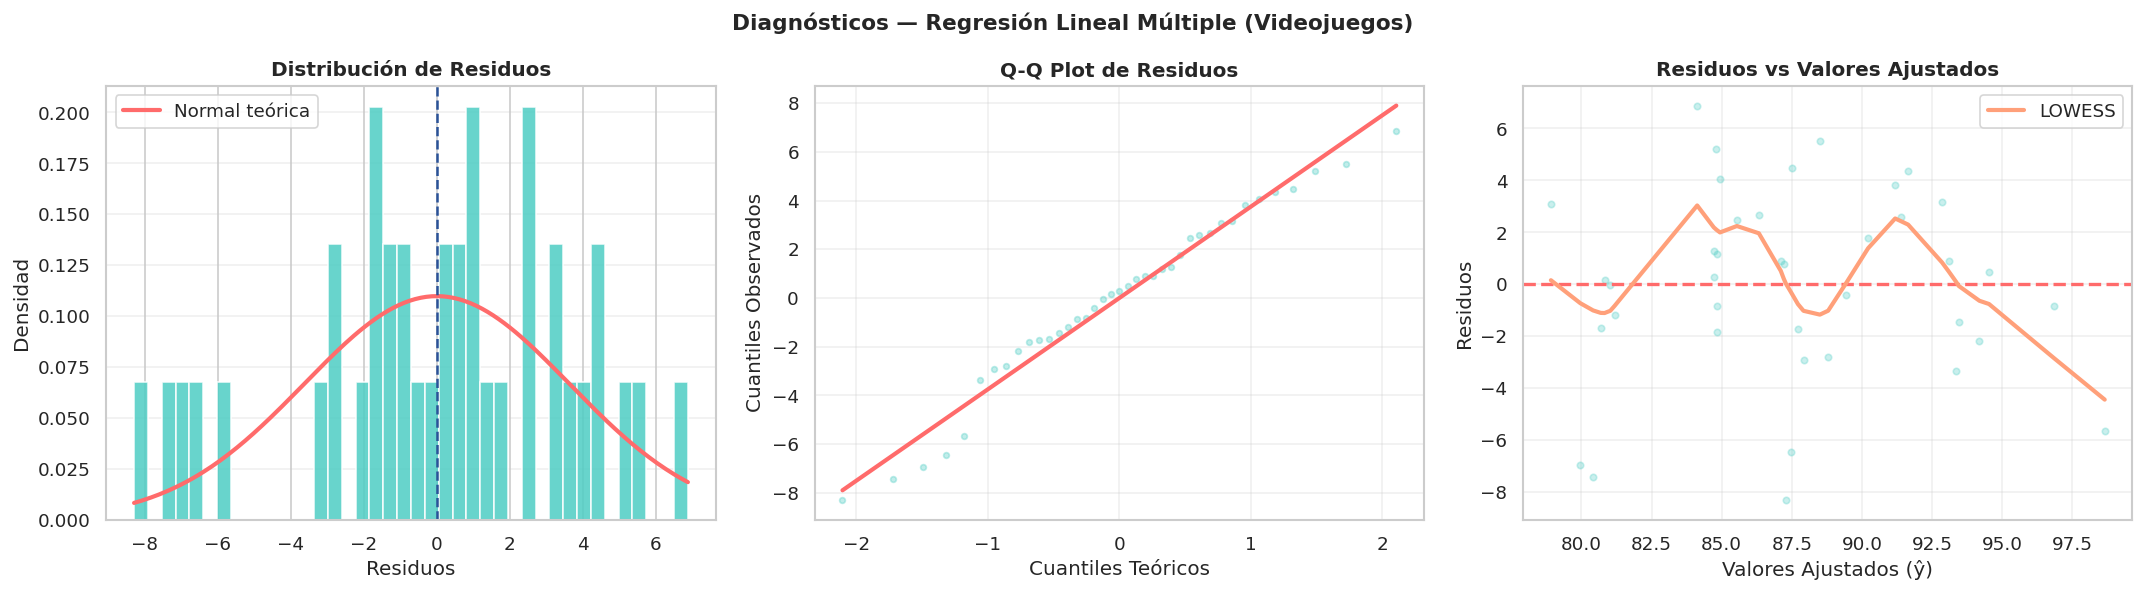


🔬 Test Shapiro-Wilk (Normalidad):
   p-value: 0.377854 → ✅ No se rechaza normalidad

🔬 Test Breusch-Pagan (Homocedasticidad):
   p-value: 0.862458 → ✅ Homocedasticidad OK


In [70]:
# ── CELDA 21: Diagnósticos completos — modelo múltiple ───────

residuos_m  = modelo_ols_multi.resid.values
ajustados_m = modelo_ols_multi.fittedvalues.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fig.suptitle('Diagnósticos — Regresión Lineal Múltiple (Videojuegos)',
             fontsize=13, fontweight='bold')

# ── 1. Histograma de residuos
axes[0].hist(residuos_m, bins=40,
             color='#4ecdc4',
             edgecolor='white',
             density=True,
             alpha=0.85)

xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)

axes[0].plot(
    xr,
    stats.norm.pdf(xr, residuos_m.mean(), residuos_m.std()),
    color='#ff6b6b',
    linewidth=2.5,
    label='Normal teórica'
)

axes[0].axvline(0, color='#2a5298', linestyle='--')

axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# ── 2. Q-Q Plot
(osm, osr), (slope, intercept, _) = stats.probplot(residuos_m, dist='norm')

axes[1].scatter(osm, osr,
                alpha=0.35,
                s=12,
                color='#4ecdc4')

axes[1].plot(
    osm,
    slope * np.array(osm) + intercept,
    color='#ff6b6b',
    linewidth=2.5
)

axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles Observados')
axes[1].grid(alpha=0.3)

# ── 3. Residuos vs Ajustados
axes[2].scatter(ajustados_m, residuos_m,
                alpha=0.30,
                s=15,
                color='#4ecdc4')

axes[2].axhline(0, color='#ff6b6b',
                linestyle='--',
                linewidth=2)

# Línea LOWESS
lowess_m = sm.nonparametric.lowess(residuos_m, ajustados_m, frac=0.3)

axes[2].plot(
    lowess_m[:, 0],
    lowess_m[:, 1],
    color='#ffa07a',
    linewidth=2.5,
    label='LOWESS'
)

axes[2].set_title('Residuos vs Valores Ajustados', fontweight='bold')
axes[2].set_xlabel('Valores Ajustados (ŷ)')
axes[2].set_ylabel('Residuos')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../data/graficas/diagnosticos_multi.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ── TESTS ESTADÍSTICOS

# Shapiro-Wilk (normalidad)
muestra_m = (
    residuos_m if len(residuos_m) <= 5000
    else np.random.default_rng(42).choice(residuos_m, 5000, replace=False)
)

stat_sw_m, p_sw_m = stats.shapiro(muestra_m)

# Breusch-Pagan (homocedasticidad)
lm_m, lm_p_m, _, _ = het_breuschpagan(
    modelo_ols_multi.resid,
    modelo_ols_multi.model.exog
)

print("\n🔬 Test Shapiro-Wilk (Normalidad):")
print(f"   p-value: {p_sw_m:.6f} → "
      f"{'✅ No se rechaza normalidad' if p_sw_m > 0.05 else '⚠️ Se rechaza normalidad'}")

print("\n🔬 Test Breusch-Pagan (Homocedasticidad):")
print(f"   p-value: {lm_p_m:.6f} → "
      f"{'✅ Homocedasticidad OK' if lm_p_m > 0.05 else '⚠️ Heterocedasticidad detectada'}")

In [71]:
# ── CELDA 22: Comparación final de modelos ───────────────────

comparacion = pd.DataFrame({
    'Modelo': ['Regresión Simple', 'Regresión Múltiple'],
    
    'Predictores': [
        '1: rating',
        '11: rating, año, edad_juego, ratings_count, added, playtime, rating_top, num_genres, num_platforms, num_developers, num_publishers'
    ],
    
    'R² (Varianza Explicada)': [
        f"{round(r2, 4)} ({r2*100:.2f}%)",
        f"{round(r2_m, 4)} ({r2_m*100:.2f}%)"
    ],
    
    'R² Ajustado': [
        f"{round(modelo_ols_simple.rsquared_adj, 4)}",
        f"{round(modelo_ols_multi.rsquared_adj, 4)}"
    ],
    
    'RMSE': [
        f"{round(rmse, 4)}",
        f"{round(rmse_m, 4)}"
    ],
    
    'MAE': [
        f"{round(mae, 4)}",
        f"{round(mae_m, 4)}"
    ],
    
    'AIC': [
        f"{round(modelo_ols_simple.aic, 2)}",
        f"{round(modelo_ols_multi.aic, 2)}"
    ],
    
    'BIC': [
        f"{round(modelo_ols_simple.bic, 2)}",
        f"{round(modelo_ols_multi.bic, 2)}"
    ],
})

print("\n" + "=" * 140)
print("  COMPARACIÓN DE MODELOS — IMPACTO DE MÚLTIPLES VARIABLES EN LA PREDICCIÓN DE METACRITIC")
print("=" * 140)
print(comparacion.to_string(index=False))
print("=" * 140)

# Análisis detallado de mejora
improvement_r2 = ((r2_m - r2) / r2) * 100
improvement_rmse = ((rmse - rmse_m) / rmse) * 100
r2_adj_improvement = modelo_ols_multi.rsquared_adj - modelo_ols_simple.rsquared_adj

print("\n📊 ANÁLISIS COMPARATIVO:")
print(f"  ✓ R² Mejoró       : {improvement_r2:+.1f}% (de {r2:.4f} a {r2_m:.4f})")
print(f"  ✓ RMSE Redujo     : {improvement_rmse:+.1f}% (error más bajo = mejor predicción)")
print(f"  ✓ R² Ajustado     : {r2_adj_improvement:+.4f} (penaliza complejidad pero sigue mejorando)")
print(f"\n🎯 Conclusión: Modelo múltiple es SUPERIOR al simple")
print(f"   • Explica {r2_m*100:.2f}% de la varianza en Metacritic")
print(f"   • AIC/BIC menores indican mejor balance ajuste-complejidad")


  COMPARACIÓN DE MODELOS — IMPACTO DE MÚLTIPLES VARIABLES EN LA PREDICCIÓN DE METACRITIC
            Modelo                                                                                                                        Predictores R² (Varianza Explicada) R² Ajustado   RMSE    MAE    AIC    BIC
  Regresión Simple                                                                                                                          1: rating       -0.1056 (-10.56%)       0.326   4.43 2.8106 238.77  242.1
Regresión Múltiple 11: rating, año, edad_juego, ratings_count, added, playtime, rating_top, num_genres, num_platforms, num_developers, num_publishers         0.2011 (20.11%)      0.5117 3.7657 2.4591 233.34 251.63

📊 ANÁLISIS COMPARATIVO:
  ✓ R² Mejoró       : -290.4% (de -0.1056 a 0.2011)
  ✓ RMSE Redujo     : +15.0% (error más bajo = mejor predicción)
  ✓ R² Ajustado     : +0.1856 (penaliza complejidad pero sigue mejorando)

🎯 Conclusión: Modelo múltiple es SUPERIOR al simple

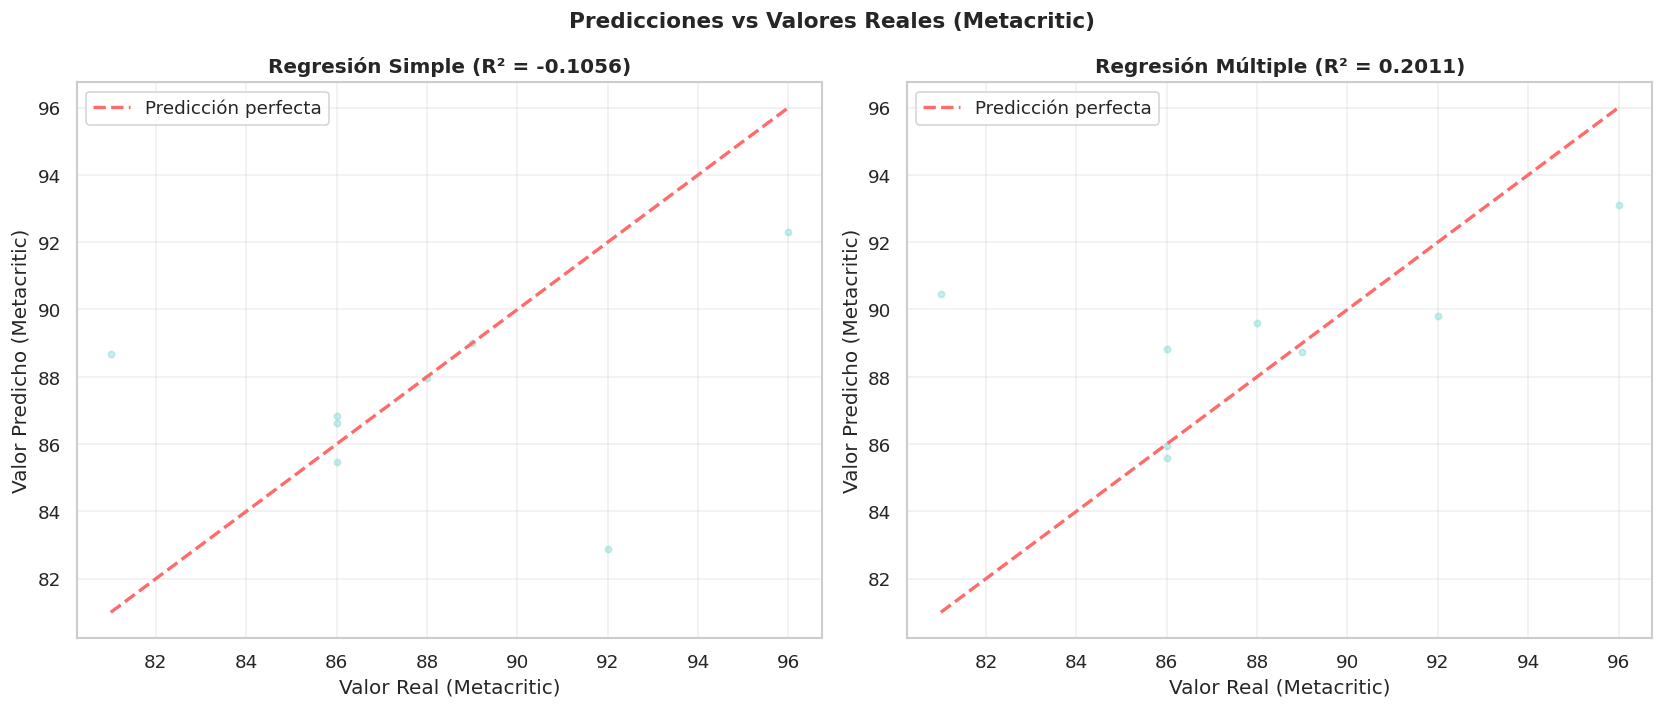

In [72]:
# ── CELDA 23: Predicciones vs Reales — ambos modelos ─────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fig.suptitle('Predicciones vs Valores Reales (Metacritic)',
             fontsize=13, fontweight='bold')

for ax, (y_real, y_pred, titulo) in zip(axes, [
    (y_test,   y_pred_simple, 'Regresión Simple'),
    (y_test_m, y_pred_multi,  'Regresión Múltiple'),
]):

    minval = min(y_real.min(), y_pred.min())
    maxval = max(y_real.max(), y_pred.max())

    ax.scatter(
        y_real,
        y_pred,
        alpha=0.30,
        s=14,
        color='#4ecdc4'
    )

    # Línea de predicción perfecta
    ax.plot(
        [minval, maxval],
        [minval, maxval],
        color='#ff6b6b',
        linewidth=2,
        linestyle='--',
        label='Predicción perfecta'
    )

    r2_val = r2_score(y_real, y_pred)

    ax.set_title(f'{titulo} (R² = {r2_val:.4f})',
                 fontweight='bold')

    ax.set_xlabel('Valor Real (Metacritic)')
    ax.set_ylabel('Valor Predicho (Metacritic)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../data/graficas/predicciones_vs_reales.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()